# Preparación de datos WO₃ para PUMA

Procesa los archivos **ASC** (PerkinElmer UV WinLab) de transmitancia de WO₃ sobre cuarzo  
a diferentes flujos de oxígeno, elimina el rango corrupto 836–860 nm, interpola,  
aplica filtro Savitzky–Golay y genera los archivos PUMA (`FNAME-dat.txt`).

| Muestra | Flujo O₂ | Espesor estimado |
|---------|----------|------------------|
| S2      | 10 sccm  | 73.000 nm        |
| S5      |  7 sccm  | 105.145 nm       |
| S8      |  5 sccm  | 136.586 nm       |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.signal import savgol_filter
from scipy.interpolate import PchipInterpolator, interp1d
import os

# ─── CONFIGURACIÓN GLOBAL ──────────────────────────────────────────────────────

SAMPLES = {
    "WO3_S2_10sccm": {
        "file"         : "WO3_datos_crudos/WO3_cuarzo_20260507_S2_10sccm_A.ASC",
        "thickness_nm" : 73.000,
        "label"        : "10 sccm – 73 nm",
        "color"        : "royalblue",
    },
    "WO3_S5_7sccm": {
        "file"         : "WO3_datos_crudos/WO3_cuarzo_20260507_S5_7sccm_A.ASC",
        "thickness_nm" : 105.145,
        "label"        : "7 sccm – 105.1 nm",
        "color"        : "darkorange",
    },
    "WO3_S8_5sccm": {
        "file"         : "WO3_datos_crudos/WO3_cuarzo_20260507_S8_5sccm_A.ASC",
        "thickness_nm" : 136.586,
        "label"        : "5 sccm – 136.6 nm",
        "color"        : "forestgreen",
    },
}

BAD_MIN = 836     # nm – inicio de zona corrupta
BAD_MAX = 860     # nm – fin de zona corrupta

# Rango para PUMA:
# - Límite inferior: 300 nm (por debajo WO3 absorbe fuerte, T < 10%, difícil de ajustar)
# - Límite superior: 1500 nm (máximo del modelo de cuarzo amorfo SUBSTRATE=60 en puma_mod.c)
# El archivo dat se guarda con rango COMPLETO; PUMA recorta internamente con estos valores.
LAMBDA_MIN_PUMA = 300
LAMBDA_MAX_PUMA = 1500

# SUBSTRATE=60: cuarzo amorfo / fused silica (Malitson 1965, 3-term Sellmeier)
# Formula corregida en puma_mod.c — n≈1.46-1.49 en 300-1500 nm
SUBSTRATE    = 60
SG_WINDOW    = 31
SG_POLY      = 3
DIR_FILTRADO = "WO3_filtrado"
DIR_RESULTS  = "WO3_result_PUMA"

os.makedirs(DIR_FILTRADO, exist_ok=True)
os.makedirs(DIR_RESULTS,  exist_ok=True)
print("Configuración cargada.")
print(f"Sustrato: SUBSTRATE={SUBSTRATE} (cuarzo amorfo, Malitson 1965)")
print(f"Rango PUMA: {LAMBDA_MIN_PUMA}–{LAMBDA_MAX_PUMA} nm")
print(f"Carpeta de salida: {os.path.abspath(DIR_FILTRADO)}")

Configuración cargada.
Sustrato: SUBSTRATE=60 (cuarzo amorfo, Malitson 1965)
Rango PUMA: 300–1500 nm
Carpeta de salida: c:\Users\Gabo\Computacional\LabAvanzadoII\WO3_filtrado


## 1. Lectura de archivos ASC (PerkinElmer)

Formato: cabecera de metadata hasta `#DATA`, luego datos **tab-separados** con **coma decimal**:  
`2000,000000\t91,265012` → 6 decimales de precisión en T.

In [14]:
def read_wo3_asc(filepath):
    """
    Lee un archivo ASC de PerkinElmer UV WinLab.
    Busca '#DATA' y lee columnas tab-separadas con decimal de coma.
    Devuelve: wl (nm, ascendente), T (fracción 0-1).
    """
    wl_list, T_list = [], []
    in_data = False
    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            if line.strip() == "#DATA":
                in_data = True
                continue
            if not in_data:
                continue
            parts = line.strip().split("\t")
            if len(parts) != 2:
                continue
            try:
                lambda_nm = float(parts[0].replace(",", "."))
                T_pct     = float(parts[1].replace(",", "."))
                wl_list.append(lambda_nm)
                T_list.append(T_pct / 100.0)
            except ValueError:
                continue
    wl  = np.array(wl_list)
    T   = np.array(T_list)
    idx = np.argsort(wl)
    return wl[idx], T[idx]


raw_data = {}
for name, info in SAMPLES.items():
    wl, T = read_wo3_asc(info["file"])
    raw_data[name] = {"wl": wl, "T": T}
    print(f"{name}: {len(wl)} puntos | λ = {wl.min():.0f}–{wl.max():.0f} nm "
          f"| T máx = {T.max()*100:.4f}%  T mín = {T.min()*100:.4f}%")

WO3_S2_10sccm: 1751 puntos | λ = 250–2000 nm | T máx = 112.0812%  T mín = 7.0477%
WO3_S5_7sccm: 1751 puntos | λ = 250–2000 nm | T máx = 112.3270%  T mín = 1.8679%
WO3_S8_5sccm: 1751 puntos | λ = 250–2000 nm | T máx = 88.5980%  T mín = 1.6115%


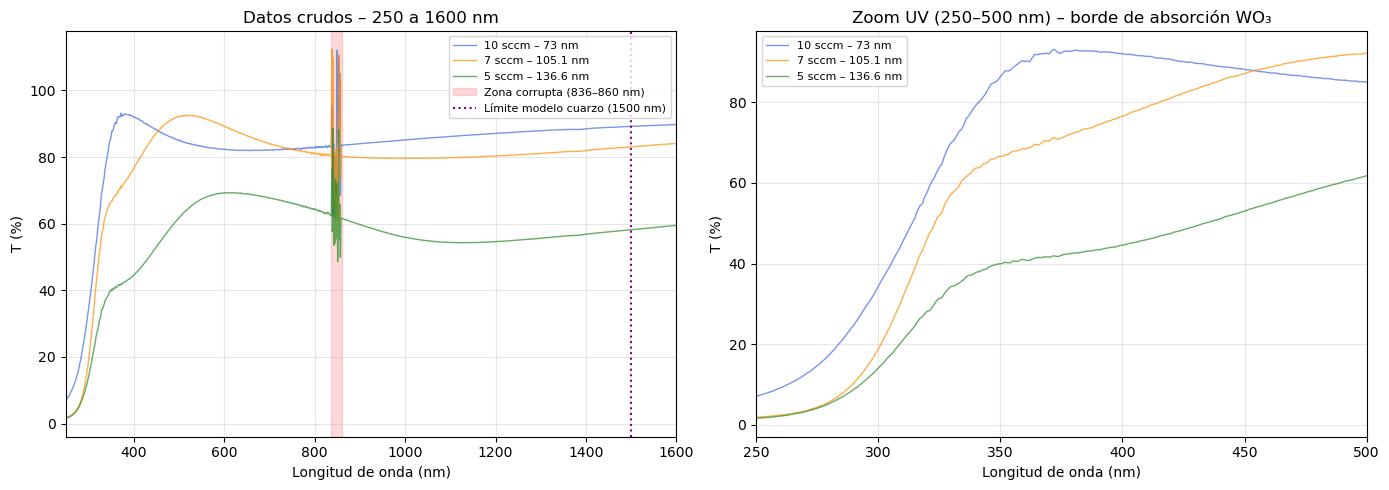

In [15]:
# Gráfica datos crudos – rango completo + zoom UV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, info in SAMPLES.items():
    wl = raw_data[name]["wl"]
    T  = raw_data[name]["T"]
    for ax, xlim in zip(axes, [(250, 1600), (250, 500)]):
        m = (wl >= xlim[0]) & (wl <= xlim[1])
        ax.plot(wl[m], T[m]*100, color=info["color"], alpha=0.7, linewidth=1,
                label=info["label"])

for ax, (lo, hi) in zip(axes, [(250, 1600), (250, 500)]):
    if lo < BAD_MAX and hi > BAD_MIN:
        ax.axvspan(BAD_MIN, min(BAD_MAX, hi), color="red", alpha=0.15,
                   label=f"Zona corrupta ({BAD_MIN}–{BAD_MAX} nm)")
    ax.axvline(LAMBDA_MAX_PUMA, color="purple", linestyle=":", linewidth=1.5,
               label=f"Límite modelo cuarzo ({LAMBDA_MAX_PUMA} nm)" if lo < LAMBDA_MAX_PUMA < hi else "")
    ax.set_xlabel("Longitud de onda (nm)")
    ax.set_ylabel("T (%)")
    ax.set_xlim(lo, hi)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_title("Datos crudos – 250 a 1600 nm")
axes[1].set_title("Zoom UV (250–500 nm) – borde de absorción WO₃")
plt.tight_layout()
plt.show()

## 2. Eliminación de zona corrupta + Filtro S-G + Guardado

El archivo dat se guarda con el **rango completo (250–2000 nm)** — PUMA recorta internamente.

In [16]:
def remove_and_interpolate(wl, T):
    """Elimina zona corrupta e interpola con PCHIP usando vecinos ±100 nm."""
    mask_good  = (wl < BAD_MIN) | (wl > BAD_MAX)
    wl_good, T_good = wl[mask_good], T[mask_good]
    margin     = 100
    mask_local = (wl_good >= BAD_MIN - margin) & (wl_good <= BAD_MAX + margin)
    interp     = PchipInterpolator(wl_good[mask_local], T_good[mask_local])
    wl_gap     = np.arange(BAD_MIN, BAD_MAX + 1, 1.0)
    T_gap      = np.clip(interp(wl_gap), 0.0, 1.0)
    wl_out     = np.concatenate([wl_good, wl_gap])
    T_out      = np.concatenate([T_good,  T_gap])
    idx        = np.argsort(wl_out)
    return wl_out[idx], T_out[idx]


def save_puma_dat(wl, T, fname_base, output_dir):
    """Guarda rango completo en formato PUMA con notación científica."""
    T_clipped = np.clip(T, 0.0, 1.0)
    n_obs     = len(wl)
    outpath   = os.path.join(output_dir, f"{fname_base}-dat.txt")
    with open(outpath, "w") as f:
        f.write(f"{n_obs}\n")
        np.savetxt(f, np.column_stack([wl, T_clipped]), fmt="%.3e")
    size_kb = os.path.getsize(outpath) / 1024
    print(f"  ✓  {os.path.basename(outpath)}  |  {n_obs} puntos | "
          f"λ = {wl.min():.0f}–{wl.max():.0f} nm | {size_kb:.1f} kB")
    return outpath


clean_data    = {}
filtered_data = {}
puma_files    = {}

print(f"Procesando → {os.path.abspath(DIR_FILTRADO)}/\n")
for name, info in SAMPLES.items():
    wl_raw, T_raw = raw_data[name]["wl"], raw_data[name]["T"]
    wl_cl, T_cl   = remove_and_interpolate(wl_raw, T_raw)
    clean_data[name] = {"wl": wl_cl, "T": T_cl}
    T_sg = np.clip(savgol_filter(T_cl, window_length=SG_WINDOW, polyorder=SG_POLY), 0.0, 1.0)
    filtered_data[name] = {"wl": wl_cl, "T": T_sg}
    path = save_puma_dat(wl_cl, T_sg, name, DIR_FILTRADO)
    puma_files[name] = path

print("\nArchivos en WO3_filtrado/:")
for fname in sorted(os.listdir(DIR_FILTRADO)):
    if fname.endswith(".txt"):
        print(f"  {fname}")

primer = puma_files[list(SAMPLES.keys())[0]]
print(f"\nPrimeras 5 líneas de {os.path.basename(primer)}:")
with open(primer) as f:
    for i, line in enumerate(f):
        print(" ", line.rstrip())
        if i == 5: break

Procesando → c:\Users\Gabo\Computacional\LabAvanzadoII\WO3_filtrado/

  ✓  WO3_S2_10sccm-dat.txt  |  1751 puntos | λ = 250–2000 nm | 35.9 kB
  ✓  WO3_S5_7sccm-dat.txt  |  1751 puntos | λ = 250–2000 nm | 35.9 kB
  ✓  WO3_S8_5sccm-dat.txt  |  1751 puntos | λ = 250–2000 nm | 35.9 kB

Archivos en WO3_filtrado/:
  WO3_S2_10sccm-dat.txt
  WO3_S5_7sccm-dat.txt
  WO3_S8_5sccm-dat.txt

Primeras 5 líneas de WO3_S2_10sccm-dat.txt:
  1751
  2.500e+02 7.033e-02
  2.510e+02 7.219e-02
  2.520e+02 7.409e-02
  2.530e+02 7.605e-02
  2.540e+02 7.807e-02


## 3. Comparación: crudo vs filtrado

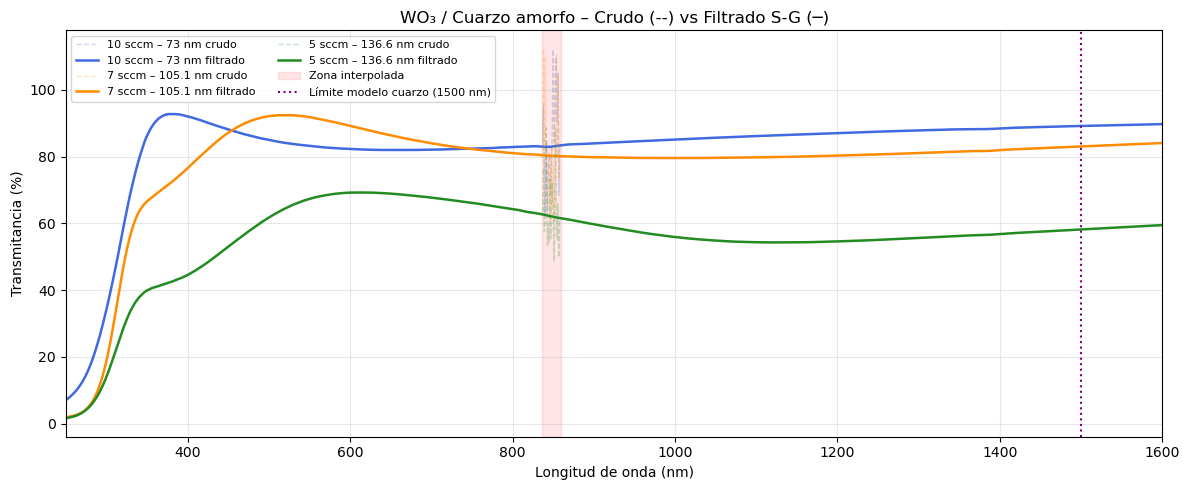

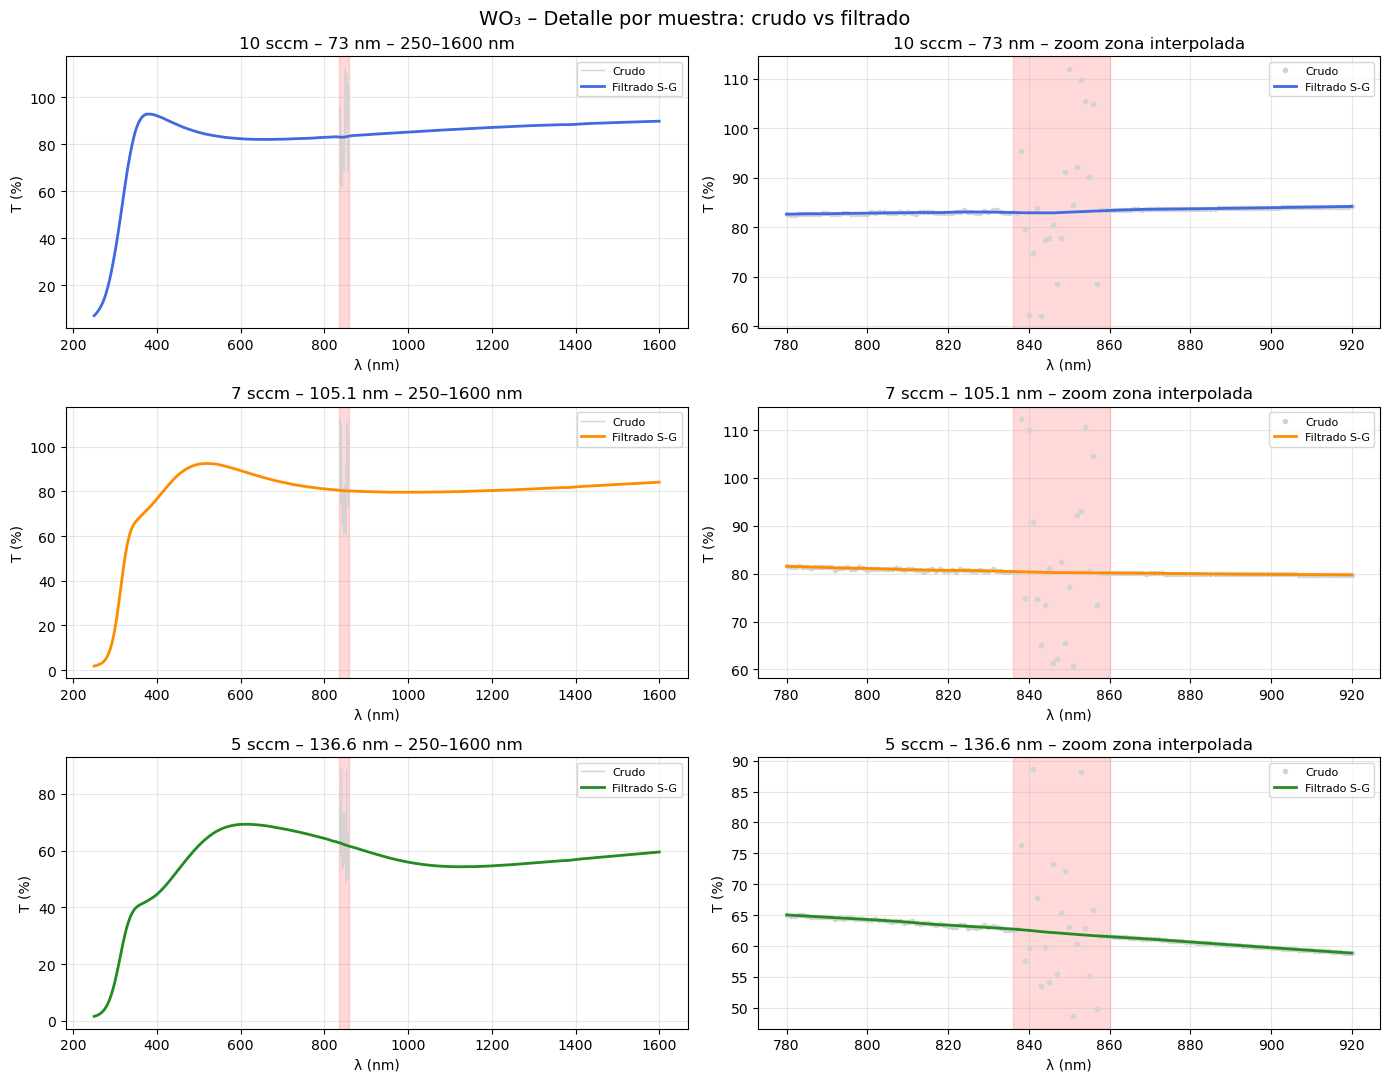

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, info in SAMPLES.items():
    wl_r = raw_data[name]["wl"]
    T_r  = raw_data[name]["T"]
    wl_f = filtered_data[name]["wl"]
    T_f  = filtered_data[name]["T"]
    mr   = (wl_r >= 250) & (wl_r <= 1600)
    mf   = (wl_f >= 250) & (wl_f <= 1600)
    ax.plot(wl_r[mr], T_r[mr]*100, color=info["color"], alpha=0.25, linewidth=1,
            linestyle="--", label=f"{info['label']} crudo")
    ax.plot(wl_f[mf], T_f[mf]*100, color=info["color"], alpha=1.0, linewidth=1.8,
            label=f"{info['label']} filtrado")
ax.axvspan(BAD_MIN, BAD_MAX, color="red", alpha=0.10, label="Zona interpolada")
ax.axvline(LAMBDA_MAX_PUMA, color="purple", linestyle=":", linewidth=1.5,
           label=f"Límite modelo cuarzo ({LAMBDA_MAX_PUMA} nm)")
ax.set_xlabel("Longitud de onda (nm)")
ax.set_ylabel("Transmitancia (%)")
ax.set_title("WO₃ / Cuarzo amorfo – Crudo (--) vs Filtrado S-G (─)")
ax.set_xlim(250, 1600)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
fig.suptitle("WO₃ – Detalle por muestra: crudo vs filtrado", fontsize=14)
for row, (name, info) in enumerate(SAMPLES.items()):
    wl_r, T_r = raw_data[name]["wl"],  raw_data[name]["T"]
    wl_f, T_f = filtered_data[name]["wl"], filtered_data[name]["T"]
    for col, (lo, hi, title) in enumerate([
        (250, 1600, f"{info['label']} – 250–1600 nm"),
        (780, 920,  f"{info['label']} – zoom zona interpolada"),
    ]):
        ax = axes[row, col]
        mr = (wl_r >= lo) & (wl_r <= hi)
        mf = (wl_f >= lo) & (wl_f <= hi)
        ax.plot(wl_r[mr], T_r[mr]*100, "o" if col else "-",
                color="lightgray", markersize=3, linewidth=1, label="Crudo")
        ax.plot(wl_f[mf], T_f[mf]*100, "-",
                color=info["color"], linewidth=2, label="Filtrado S-G")
        ax.axvspan(max(BAD_MIN, lo), min(BAD_MAX, hi), color="red", alpha=0.15)
        ax.set_title(title)
        ax.set_xlabel("λ (nm)")
        ax.set_ylabel("T (%)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Comandos PUMA – First Call

### Estrategia para 6 horas de cluster

El costo computacional de PUMA escala como el **producto** de todos los valores del barrido:  
`N_d × N_ip × N_n0 × N_nf × N_k0 × maxIT`

Para el first call usamos **pasos gruesos** que cubran el espacio de parámetros sin saturar el cluster:

| Parámetro | Estrategia first call | Razonamiento |
|-----------|----------------------|---------------|
| Espesor   | ±20%, paso 2 nm | Conocemos el valor nominal |
| Inflexión | rango completo, paso 100 nm | Exploración amplia pero gruesa |
| n₀, n_f   | rango WO₃ literatura, **paso 0.1** | Evitar el paso fino 0.05 del ITO |
| k₀        | 0.25–0.55, **paso 0.05** | k≈0.45 en 300 nm (Fig. 4.3a), k≈0 en 1500 nm; margen ±15% |
| maxIT     | **3000** | Balance convergencia / tiempo de cluster |

WO₃ literatura (visible-NIR): n ≈ 1.87–2.4, k ≈ 0.45 en borde UV (300 nm), k → 0 en NIR (1500 nm).

In [18]:
PUMA_PARAMS = {
    "NLAYERS"   : 4,
    "SLAYER"    : 2,
    "SUBSTRATE" : SUBSTRATE,          # 60 = cuarzo amorfo (Malitson 1965, corregido)
    "DATATYPE"  : "T",
    "NOBS"      : 100,
    "LAMBDAmin" : LAMBDA_MIN_PUMA,    # 300 nm
    "LAMBDAmax" : LAMBDA_MAX_PUMA,    # 1500 nm
    "maxIT"     : 3000,
    "QUAD"      : "1e+100",
    "INIT"      : 0,
    "INFLEmin"  : LAMBDA_MIN_PUMA,
    "INFLEmax"  : LAMBDA_MAX_PUMA,
    "INFLEstep" : 100,                # (1500-300)/100+1 = 13 valores
    # n(λ): WO₃ literatura, paso 0.10
    "N0ini"     : 1.90,  "N0fin"  : 2.50,  "N0step"  : 0.10,   # 7 valores
    "NFini"     : 1.80,  "NFfin"  : 2.20,  "NFstep"  : 0.10,   # 5 valores
    # k(λ): Literatura (Fig. 4.3a): k≈0.45 en 300 nm, k→0 en 1500 nm; margen ±15%
    "K0ini"     : 0.25,  "K0fin"  : 0.55,  "K0step"  : 0.05,   # 7 valores
}
THICKNESS_MARGIN = 0.20
THICKNESS_STEP   = 2

print("=" * 80)
print("COMANDOS PUMA – FIRST CALL")
print("=" * 80)

total_calls = 0
for name, info in SAMPLES.items():
    d     = info["thickness_nm"]
    d_min = int(d * (1 - THICKNESS_MARGIN))
    d_max = int(d * (1 + THICKNESS_MARGIN)) + 1
    p     = PUMA_PARAMS

    N_d   = len(range(d_min, d_max + 1, THICKNESS_STEP))
    N_ip  = int((p["INFLEmax"] - p["INFLEmin"]) / p["INFLEstep"]) + 1
    N_n0  = int(round((p["N0fin"]   - p["N0ini"])   / p["N0step"]))   + 1
    N_nf  = int(round((p["NFfin"]   - p["NFini"])   / p["NFstep"]))   + 1
    N_k0  = int(round((p["K0fin"]   - p["K0ini"])   / p["K0step"]))   + 1
    calls = N_d * N_ip * N_n0 * N_nf * N_k0
    total_calls += calls

    cmd = (
        f"./puma_mod {name} "
        f"{p['NLAYERS']} {p['SLAYER']} {p['SUBSTRATE']} {p['DATATYPE']} "
        f"{p['NOBS']} "
        f"{p['LAMBDAmin']:04d} {p['LAMBDAmax']:04d} "
        f"{p['maxIT']} {p['QUAD']} {p['INIT']} "
        f"{d_min:04d} {d_max:04d} {THICKNESS_STEP} "
        f"{p['INFLEmin']:04d} {p['INFLEmax']:04d} {p['INFLEstep']} "
        f"{p['N0ini']:.2f} {p['N0fin']:.2f} {p['N0step']:.2f} "
        f"{p['NFini']:.2f} {p['NFfin']:.2f} {p['NFstep']:.2f} "
        f"{p['K0ini']:.2f} {p['K0fin']:.2f} {p['K0step']:.2f}"
    )
    print(f"\n# {info['label']}  (d = {d} nm  →  barrido {d_min}–{d_max} nm, paso {THICKNESS_STEP})")
    print(f"# Llamadas al optimizador: {N_d}d × {N_ip}ip × {N_n0}n0 × {N_nf}nf × {N_k0}k0 = {calls:,}")
    print(cmd)

print(f"\n{'='*80}")
print(f"Total llamadas al optimizador (3 muestras): {total_calls:,}")
print(f"Iteraciones totales estimadas: ~{total_calls * p['maxIT']:,}")

COMANDOS PUMA – FIRST CALL

# 10 sccm – 73 nm  (d = 73.0 nm  →  barrido 58–88 nm, paso 2)
# Llamadas al optimizador: 16d × 13ip × 7n0 × 5nf × 7k0 = 50,960
./puma_mod WO3_S2_10sccm 4 2 60 T 100 0300 1500 3000 1e+100 0 0058 0088 2 0300 1500 100 1.90 2.50 0.10 1.80 2.20 0.10 0.25 0.55 0.05

# 7 sccm – 105.1 nm  (d = 105.145 nm  →  barrido 84–127 nm, paso 2)
# Llamadas al optimizador: 22d × 13ip × 7n0 × 5nf × 7k0 = 70,070
./puma_mod WO3_S5_7sccm 4 2 60 T 100 0300 1500 3000 1e+100 0 0084 0127 2 0300 1500 100 1.90 2.50 0.10 1.80 2.20 0.10 0.25 0.55 0.05

# 5 sccm – 136.6 nm  (d = 136.586 nm  →  barrido 109–164 nm, paso 2)
# Llamadas al optimizador: 28d × 13ip × 7n0 × 5nf × 7k0 = 89,180
./puma_mod WO3_S8_5sccm 4 2 60 T 100 0300 1500 3000 1e+100 0 0109 0164 2 0300 1500 100 1.90 2.50 0.10 1.80 2.20 0.10 0.25 0.55 0.05

Total llamadas al optimizador (3 muestras): 210,210
Iteraciones totales estimadas: ~630,630,000


## Tabla de parámetros – First Call

| Parámetro | Valor | Significado |
|-----------|-------|-------------|
| `NLAYERS` | 4 | aire / WO₃ / cuarzo / aire |
| `SLAYER` | 2 | capa sustrato = cuarzo |
| `SUBSTRATE` | **60** | cuarzo amorfo / fused silica — Malitson 1965 (corregido en `puma_mod.c`) |
| `DATATYPE` | T | transmitancia |
| `NOBS` | 100 | puntos equiespaciados para el ajuste |
| `LAMBDAmin` | 300 nm | por debajo WO₃ absorbe fuerte (T < 10%) |
| `LAMBDAmax` | 1500 nm | límite del modelo de cuarzo en PUMA |
| `maxIT` | 3000 | balance entre convergencia y tiempo de cluster |
| `QUAD` | 1e+100 | sin cota de error (first call) |
| `INIT` | 0 | estimación inicial desde cero |
| `THICKNESSstep` | 2 nm | paso grueso para first call |
| `INFLEstep` | 100 nm | exploración gruesa del punto de inflexión |
| `N0ini/fin` | 1.90 / 2.50 | n en λ_min; extendido a 1.90 (±15% sobre n≈2.2) |
| `NFini/fin` | 1.80 / 2.20 | n en λ_max — WO₃ literatura |
| `N0/NFstep` | 0.10 | **paso grueso** (vs 0.05 del ITO) |
| `K0ini/fin` | 0.25 / 0.55 | k≈0.45 en 300 nm (Fig. 4.3a) ±15%; k→0 en 1500 nm |
| `K0step` | 0.05 | 7 valores: 0.25, 0.30, …, 0.55 |

> **Antes de lanzar:** recompilar `puma_mod.c` en el cluster con `gcc -O4 -lm puma_mod.c -o puma_mod`  
> **Después del first call:** revisar `FNAME-inf.txt`, anotar espesor, inflexión y error cuadrático,  
> y afinar con second call (`INIT=9`, paso más fino, `maxIT=5000`).

## 5. Resultados PUMA – Análisis de `-inf.txt`

Copia los archivos `*-inf.txt` del cluster a la carpeta `WO3_result_PUMA/` antes de correr esta sección.

Para cada muestra se extraen:
- **n(λ)** y **k(λ)** de la sección `REFRACTIVE INDICES AND ABSORPTION`
- **T simulada** de la sección `TRANSMITTANCE WITH THE ESTIMATED`

y se comparan contra los datos experimentales filtrados en el mismo rango que la simulación.

In [10]:
import os
import numpy as np
import glob

# ── CONFIGURACIÓN ──────────────────────────────────────────────────────────────
DIR_RESULTS = r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3_result_PUMA"

# Muestras a considerar — agrega o quita según tus archivos
SAMPLES = ["WO3_S2_10sccm", "WO3_S5_7sccm", "WO3_S8_5sccm"]

# Pruebas que quieres graficar por muestra
# Formato: {nombre_muestra: [lista de pruebas]}
# Deja la lista vacía [] para cargar todas las pruebas disponibles de esa muestra
# Ejemplo: {"WO3_S5_7sccm": ["P1", "P3"]} grafica solo P1 y P3 de S5
SELECCION = {
    "WO3_S2_10sccm" : [],   # [] = todas las disponibles
    "WO3_S5_7sccm"  : [],
    "WO3_S8_5sccm"  : [],
}

# ── PARSER ─────────────────────────────────────────────────────────────────────
def parse_puma_inf(filepath):
    """
    Lee un archivo PUMA *-inf.txt y extrae:
      - wl_nk, n, k   (sección REFRACTIVE INDICES AND ABSORPTION)
      - wl_t,  T_sim  (sección TRANSMITTANCE WITH THE ESTIMATED)
      - thickness     (ESTIMATED THICKNESSES)
      - inflexion     (ESTIMATED INFLEXION POINTS)
    Devuelve un dict o None si el archivo no existe o está incompleto.
    """
    if not os.path.exists(filepath):
        return None

    block_nk, block_t = [], []
    section    = None
    thickness  = None
    inflexion  = None

    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            ls = line.strip()

            # Extraer espesor
            if "Thickness of film 1" in ls:
                try:
                    thickness = float(ls.split("=")[-1].strip().split()[0])
                except:
                    pass

            # Extraer punto de inflexión
            if "Inflexion point" in ls:
                try:
                    inflexion = float(ls.split("=")[-1].strip().split()[0])
                except:
                    pass

            # Detectar secciones
            if "REFRACTIVE INDICES AND ABSORPTION" in ls:
                section = "nk"; continue
            if "TRANSMITTANCE WITH THE ESTIMATED" in ls:
                section = "t";  continue
            if "QUADRATIC ERROR" in ls:
                try:
                    qe = float(ls.split("=")[-1].strip())
                except:
                    qe = None

            if not ls or ls.startswith("lambda") or ls.startswith("Film"):
                continue

            try:
                vals = list(map(float, ls.split()))
                if section == "nk" and len(vals) == 3:
                    block_nk.append(vals)
                elif section == "t" and len(vals) == 2:
                    block_t.append(vals)
            except ValueError:
                continue

    if not block_nk or not block_t:
        print(f"  ⚠  {os.path.basename(filepath)}: secciones incompletas")
        return None

    nk = np.array(block_nk)
    t  = np.array(block_t)

    return {
        "wl_nk"    : nk[:, 0],
        "n"        : nk[:, 1],
        "k"        : nk[:, 2],
        "wl_t"     : t[:, 0],
        "T_sim"    : t[:, 1],
        "thickness": thickness,
        "inflexion": inflexion,
        "qe"       : qe if 'qe' in dir() else None,
        "filepath" : filepath,
    }


# ── ESCANEAR ARCHIVOS DISPONIBLES ──────────────────────────────────────────────
def escanear_pruebas(sample, dir_results, seleccion):
    """
    Busca todos los archivos que coincidan con:
        {sample}*P*-inf.txt   (con etiqueta de prueba)
        {sample}-inf.txt      (sin etiqueta, prueba base)
    Filtra según la selección indicada.
    """
    # Archivos con etiqueta de prueba: WO3_S5_7sccm_P1-inf.txt
    patron_etiqueta = os.path.join(dir_results, f"{sample}*P*-inf.txt")
    archivos = sorted(glob.glob(patron_etiqueta))

    # Archivo base sin etiqueta: WO3_S5_7sccm-inf.txt
    archivo_base = os.path.join(dir_results, f"{sample}-inf.txt")
    if os.path.exists(archivo_base):
        archivos = [archivo_base] + archivos

    if not archivos:
        return {}

    resultados = {}
    for fp in archivos:
        nombre = os.path.basename(fp).replace("-inf.txt", "")

        # Extraer etiqueta de prueba del nombre
        if "_P" in nombre:
            etiqueta = nombre.split("_P")[-1]   # "1", "2", etc.
            etiqueta = f"P{etiqueta}"
        else:
            etiqueta = "base"

        # Filtrar según selección
        sel = seleccion.get(sample, [])
        if sel and etiqueta not in sel and etiqueta != "base":
            continue

        res = parse_puma_inf(fp)
        if res is not None:
            resultados[etiqueta] = res

    return resultados


# ── CARGAR TODOS LOS RESULTADOS ────────────────────────────────────────────────
print("Escaneando resultados PUMA...\n")
puma_results = {}

for sample in SAMPLES:
    pruebas = escanear_pruebas(sample, DIR_RESULTS, SELECCION)

    if not pruebas:
        print(f"  –  {sample}: sin archivos -inf.txt en {DIR_RESULTS}/")
        continue

    puma_results[sample] = pruebas
    print(f"  {sample}:")

    for etiqueta, res in pruebas.items():
        d   = f"{res['thickness']:.1f} nm" if res['thickness'] else "?"
        inf = f"{res['inflexion']:.0f} nm" if res['inflexion'] else "?"
        qe  = f"{res['qe']:.2e}"           if res['qe']       else "?"
        pts = len(res['wl_nk'])
        print(f"    [{etiqueta}]  d={d}  inflexión={inf}  QE={qe}  ({pts} puntos)")

print(f"\nTotal muestras cargadas: {len(puma_results)}")


# ── EJEMPLO DE ACCESO ──────────────────────────────────────────────────────────
# Para acceder a los datos de una prueba específica:
#
#   res = puma_results["WO3_S5_7sccm"]["P2"]
#   wl  = res["wl_nk"]
#   n   = res["n"]
#   k   = res["k"]
#
# Para iterar sobre todas las pruebas de una muestra:
#
#   for etiqueta, res in puma_results["WO3_S5_7sccm"].items():
#       plt.plot(res["wl_nk"], res["n"], label=etiqueta)

Escaneando resultados PUMA...

  WO3_S2_10sccm:
    [P1]  d=95.0 nm  inflexión=400 nm  QE=3.04e-05  (100 puntos)
    [P2]  d=95.0 nm  inflexión=400 nm  QE=2.89e-05  (100 puntos)
    [P3]  d=95.0 nm  inflexión=380 nm  QE=2.65e-05  (100 puntos)
    [P4]  d=95.0 nm  inflexión=350 nm  QE=2.65e-05  (100 puntos)
  WO3_S5_7sccm:
    [P1]  d=130.0 nm  inflexión=400 nm  QE=6.23e-05  (100 puntos)
    [P2]  d=130.0 nm  inflexión=350 nm  QE=6.18e-05  (100 puntos)
    [P3]  d=130.0 nm  inflexión=350 nm  QE=6.18e-05  (100 puntos)
    [P4]  d=131.0 nm  inflexión=340 nm  QE=5.06e-05  (100 puntos)
    [P5]  d=131.0 nm  inflexión=330 nm  QE=5.06e-05  (100 puntos)
    [P6]  d=131.0 nm  inflexión=330 nm  QE=5.03e-05  (100 puntos)
  WO3_S8_5sccm:
    [P1]  d=105.0 nm  inflexión=550 nm  QE=9.68e-03  (100 puntos)
    [P2]  d=105.0 nm  inflexión=700 nm  QE=5.12e-03  (100 puntos)

Total muestras cargadas: 3


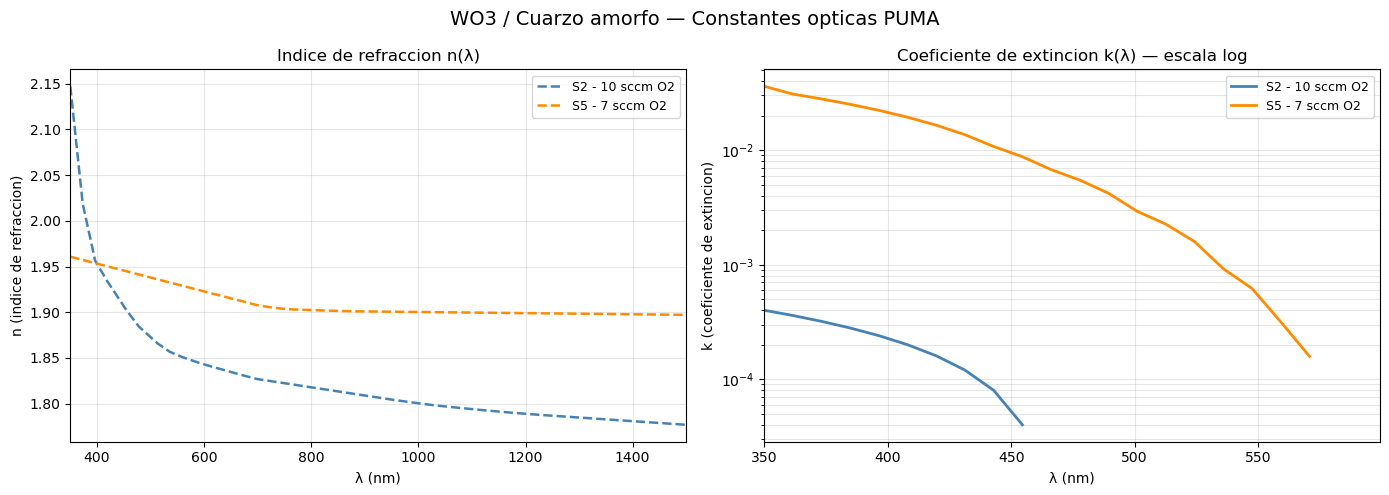

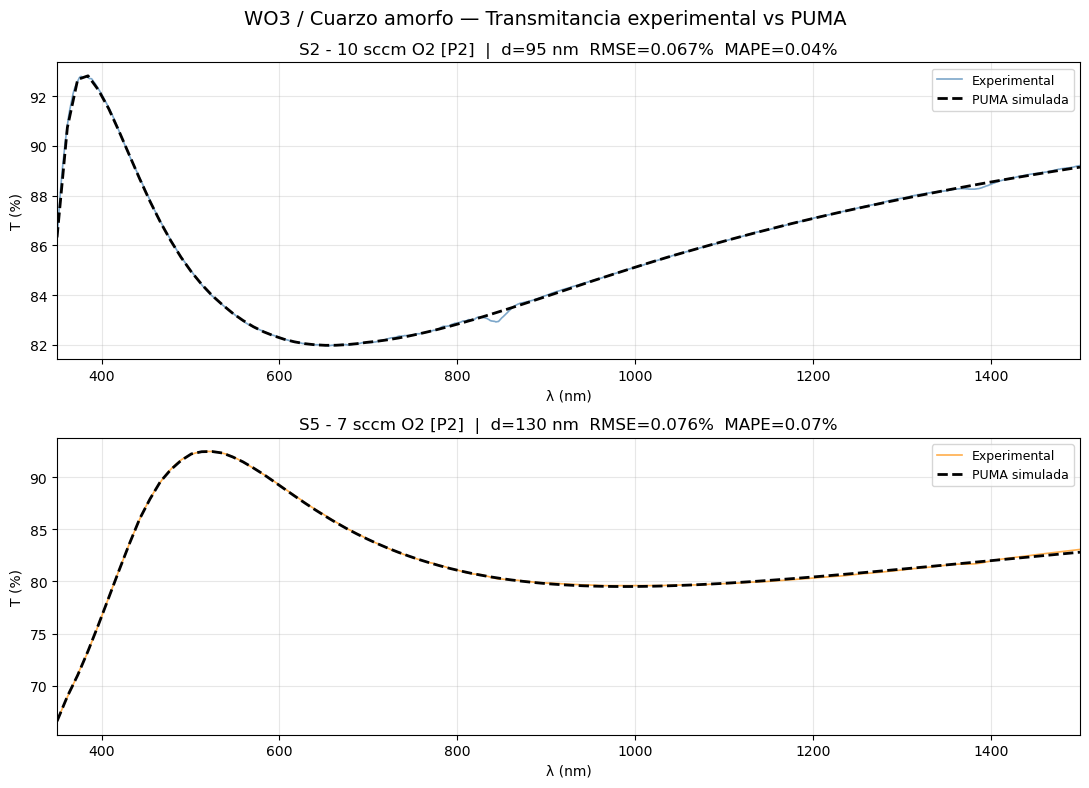


Band gap estimado (transicion indirecta):
  [indirecto] S2 - 10 sccm O2 [P2]: Eg = 2.27 eV  (546 nm)  R²=0.9991
  [indirecto] S5 - 7 sccm O2 [P2]: Eg = 2.11 eV  (587 nm)  R²=0.9995


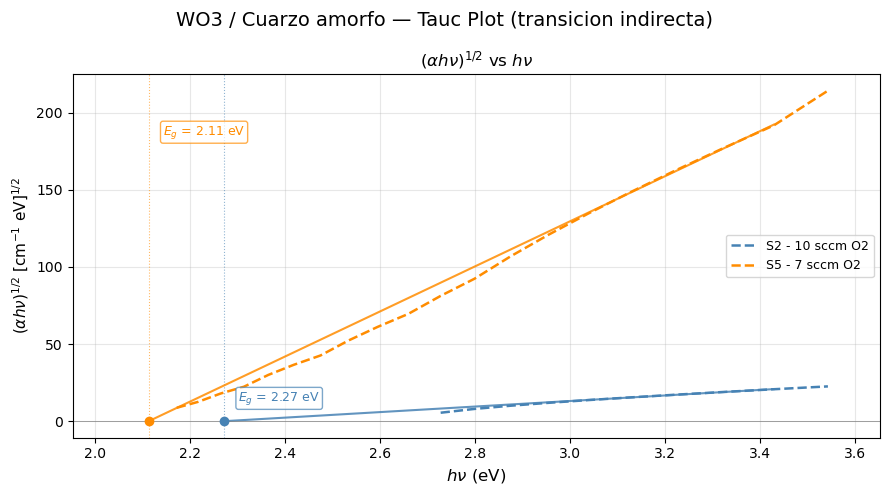

In [12]:
from scipy.interpolate import interp1d

# ── CONFIGURACIÓN DE GRÁFICAS ──────────────────────────────────────────────────
LAMBDA_MIN_PUMA = 350
LAMBDA_MAX_PUMA = 1500
hc_eV_nm = 1239.84   # eV·nm

# Colores y etiquetas por muestra
SAMPLE_INFO = {
    "WO3_S2_10sccm": {"color": "steelblue",  "label": "S2 - 10 sccm O2"},
    "WO3_S5_7sccm" : {"color": "darkorange", "label": "S5 - 7 sccm O2"},
    "WO3_S8_5sccm" : {"color": "seagreen",   "label": "S8 - 5 sccm O2"},
}

# Archivos experimentales por muestra
EXP_FILES = {
    "WO3_S2_10sccm": r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3_filtrado\WO3_S2_10sccm-dat.txt",
    "WO3_S5_7sccm" : r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3_filtrado\WO3_S5_7sccm-dat.txt",
    "WO3_S8_5sccm" : r"C:\Users\Gabo\Computacional\LabAvanzadoII\WO3_filtrado\WO3_S8_5sccm-dat.txt",
}

# ── SELECCIÓN DE QUÉ GRAFICAR ──────────────────────────────────────────────────
# [] o None = todas las pruebas de esa muestra
# ["P1", "P3"] = solo esas pruebas
# Omite una muestra del dict para no graficarla
GRAFICAR = {
    "WO3_S2_10sccm": ["P2"],
    "WO3_S5_7sccm" : ["P2"],
    # "WO3_S8_5sccm": [],
}

# ── FILTRAR RESULTADOS ─────────────────────────────────────────────────────────
def filtrar_resultados(puma_results, graficar):
    resultado = {}
    for sample, pruebas_sel in graficar.items():
        if sample not in puma_results:
            print(f"  ? {sample} no encontrado en puma_results")
            continue
        pruebas = puma_results[sample]
        if not pruebas_sel:
            resultado[sample] = pruebas
        else:
            filtradas = {e: r for e, r in pruebas.items() if e in pruebas_sel}
            if not filtradas:
                print(f"  ? {sample}: ninguna de {pruebas_sel} encontrada "
                      f"(disponibles: {list(pruebas.keys())})")
            else:
                resultado[sample] = filtradas
    return resultado

resultados_plot = filtrar_resultados(puma_results, GRAFICAR)

# ── CARGAR EXPERIMENTALES ──────────────────────────────────────────────────────
filtered_data = {}
for sample, path in EXP_FILES.items():
    if os.path.exists(path):
        d = np.loadtxt(path, skiprows=1)
        filtered_data[sample] = {"wl": d[:, 0], "T": d[:, 1]}
    else:
        print(f"  ? Experimental no encontrado: {path}")

# ── FUNCIÓN TAUC ───────────────────────────────────────────────────────────────
def tauc_plot(ax, resultados_plot, SAMPLE_INFO, hc_eV_nm, potencia, titulo, ylabel):
    hnu_min_all, hnu_max_all = np.inf, -np.inf

    for sample, pruebas in resultados_plot.items():
        info = SAMPLE_INFO.get(sample, {"color": "gray", "label": sample})
        for etiqueta, res in pruebas.items():
            wl = res["wl_nk"]
            k  = res["k"]

            # Incluir cola izquierda (k > 1e-10) para graficar forma de S
            mask_all = k > 1e-10
            if not mask_all.any():
                continue

            wl_all  = wl[mask_all]
            k_all   = k[mask_all]
            hnu_all = hc_eV_nm / wl_all
            alpha_all = 4 * np.pi * k_all / (wl_all * 1e-7)
            tauc_all  = (alpha_all * hnu_all) ** potencia

            idx      = np.argsort(hnu_all)
            hnu_all  = hnu_all[idx]
            tauc_all = tauc_all[idx]

            hnu_min_all = min(hnu_min_all, hnu_all.min())
            hnu_max_all = max(hnu_max_all, hnu_all.max())

            ls    = "-" if etiqueta in ("base", "P1") else "--"
            label = f"{info['label']} [{etiqueta}]" if len(pruebas) > 1 else info["label"]
            ax.plot(hnu_all, tauc_all, color=info["color"], linewidth=1.8,
                    linestyle=ls, label=label)

            # Regresion lineal — solo puntos con k > 1e-6 (fisicamente significativos)
            mask_lin = k[mask_all][idx] > 1e-6
            hnu_lin  = hnu_all[mask_lin]
            tauc_lin = tauc_all[mask_lin]

            if not mask_lin.any():
                continue

            t_max = tauc_lin.max()

            # Zona lineal adaptativa:
            # Busca la region con mejor R² usando ventanas deslizantes
            best_r2   = -np.inf
            best_mask = None
            window    = max(5, len(hnu_lin) // 4)  # ventana = 25% de los puntos

            for start in range(len(hnu_lin) - window):
                w_mask = np.zeros(len(hnu_lin), dtype=bool)
                w_mask[start:start + window] = True
                if w_mask.sum() < 3:
                    continue
                c = np.polyfit(hnu_lin[w_mask], tauc_lin[w_mask], 1)
                if c[0] <= 0:   # pendiente debe ser positiva
                    continue
                residuals = tauc_lin[w_mask] - np.polyval(c, hnu_lin[w_mask])
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((tauc_lin[w_mask] - tauc_lin[w_mask].mean())**2)
                r2 = 1 - ss_res / ss_tot if ss_tot > 0 else -np.inf
                if r2 > best_r2:
                    best_r2   = r2
                    best_mask = w_mask

            if best_mask is None or best_r2 < 0.98:
                # Fallback: zona 20-70% del maximo
                best_mask = (tauc_lin >= 0.20 * t_max) & (tauc_lin <= 0.70 * t_max)

            lin_mask = best_mask

            if lin_mask.sum() >= 3:
                coeffs = np.polyfit(hnu_lin[lin_mask], tauc_lin[lin_mask], 1)
                poly   = np.poly1d(coeffs)
                Eg     = -coeffs[1] / coeffs[0]

                # Eg debe ser positivo y dentro del rango fisico (0.5-6 eV)
                if not (0.5 < Eg < 6.0):
                    tipo = "indirecto" if potencia == 0.5 else "directo"
                    print(f"  [{tipo}] {info['label']} [{etiqueta}]: "
                          f"Eg fuera de rango fisico ({Eg:.2f} eV) — omitido")
                    continue

                hnu_line_ext = np.linspace(Eg, hnu_lin[lin_mask].max(), 100)
                ax.plot(hnu_line_ext, poly(hnu_line_ext),
                        color=info["color"], linewidth=1.5,
                        linestyle="-", alpha=0.85)
                ax.plot(Eg, 0, "o", color=info["color"], markersize=6, zorder=5)
                ax.axvline(Eg, color=info["color"], linewidth=0.8,
                           linestyle=":", alpha=0.6)
                ax.text(Eg + 0.03, t_max * 0.90,
                        f"$E_g$ = {Eg:.2f} eV",
                        fontsize=9, color=info["color"],
                        va="top", ha="left",
                        bbox=dict(boxstyle="round,pad=0.2",
                                  facecolor="white", edgecolor=info["color"],
                                  alpha=0.7))
                tipo = "indirecto" if potencia == 0.5 else "directo"
                print(f"  [{tipo}] {info['label']} [{etiqueta}]: "
                      f"Eg = {Eg:.2f} eV  ({hc_eV_nm/Eg:.0f} nm)  R²={best_r2:.4f}")

    margen = (hnu_max_all - hnu_min_all) * 0.08
    ax.set_xlim(hnu_min_all - margen * 2, hnu_max_all + margen)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_xlabel(r"$h\nu$ (eV)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# ── GRÁFICAS ───────────────────────────────────────────────────────────────────
if not resultados_plot:
    print("Sin resultados — saltando graficas.")
else:
    # ── 1. n(λ) lineal  |  k(λ) logarítmico ──────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("WO3 / Cuarzo amorfo — Constantes opticas PUMA", fontsize=14)

    for sample, pruebas in resultados_plot.items():
        info = SAMPLE_INFO.get(sample, {"color": "gray", "label": sample})
        for etiqueta, res in pruebas.items():
            ls    = "-" if etiqueta in ("base", "P1") else "--" if "2" in etiqueta else ":"
            label = f"{info['label']} [{etiqueta}]" if len(pruebas) > 1 else info["label"]
            axes[0].plot(res["wl_nk"], res["n"],
                         color=info["color"], linewidth=1.8, linestyle=ls, label=label)
            wl_k = res["wl_nk"]
            k    = res["k"].copy()
            k[k < 1e-6] = np.nan
            axes[1].plot(wl_k, k, color=info["color"], linewidth=2.0,
                         linestyle="-", label=label)

    axes[0].set_xlabel("λ (nm)")
    axes[0].set_ylabel("n (indice de refraccion)")
    axes[0].set_title("Indice de refraccion n(λ)")
    axes[0].set_xlim(LAMBDA_MIN_PUMA, LAMBDA_MAX_PUMA)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    wl_max_k = LAMBDA_MIN_PUMA
    for sample, pruebas in resultados_plot.items():
        for etiqueta, res in pruebas.items():
            wl_valid = res["wl_nk"][res["k"] > 1e-6]
            if len(wl_valid) > 0:
                wl_max_k = max(wl_max_k, wl_valid.max())

    axes[1].set_xlabel("λ (nm)")
    axes[1].set_ylabel("k (coeficiente de extincion)")
    axes[1].set_title("Coeficiente de extincion k(λ) — escala log")
    axes[1].set_xlim(LAMBDA_MIN_PUMA, wl_max_k * 1.05)
    axes[1].set_yscale("log")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3, which="both")

    plt.tight_layout()
    plt.show()

    # ── 2. T experimental vs simulada ─────────────────────────────────────────
    filas = [
        (sample, etiqueta, res)
        for sample, pruebas in resultados_plot.items()
        for etiqueta, res in pruebas.items()
    ]

    fig, axes = plt.subplots(len(filas), 1,
                             figsize=(11, 4 * len(filas)),
                             squeeze=False)
    fig.suptitle("WO3 / Cuarzo amorfo — Transmitancia experimental vs PUMA",
                 fontsize=14)

    for row, (sample, etiqueta, res) in enumerate(filas):
        info = SAMPLE_INFO.get(sample, {"color": "gray", "label": sample})
        ax   = axes[row, 0]
        lam_lo = res["wl_t"].min()
        lam_hi = res["wl_t"].max()

        if sample in filtered_data:
            wl_exp = filtered_data[sample]["wl"]
            T_exp  = filtered_data[sample]["T"]
            mask   = (wl_exp >= lam_lo) & (wl_exp <= lam_hi)
            wl_exp = wl_exp[mask]
            T_exp  = T_exp[mask]

            T_sim_interp = interp1d(res["wl_t"], res["T_sim"],
                                    kind="linear", bounds_error=False,
                                    fill_value="extrapolate")(wl_exp)
            rmse = np.sqrt(np.mean((T_sim_interp - T_exp) ** 2))
            mape = np.mean(np.abs(T_sim_interp - T_exp) /
                           np.clip(T_exp, 1e-6, None)) * 100

            ax.plot(wl_exp, T_exp * 100, color=info["color"],
                    linewidth=1.2, alpha=0.7, label="Experimental")
            titulo = (f"{info['label']} [{etiqueta}]  |  "
                      f"d={res['thickness']:.0f} nm  "
                      f"RMSE={rmse*100:.3f}%  MAPE={mape:.2f}%")
        else:
            titulo = f"{info['label']} [{etiqueta}]  |  d={res['thickness']:.0f} nm"

        ax.plot(res["wl_t"], res["T_sim"] * 100, color="black",
                linewidth=2, linestyle="--", label="PUMA simulada")
        ax.set_xlabel("λ (nm)")
        ax.set_ylabel("T (%)")
        ax.set_title(titulo)
        ax.set_xlim(lam_lo, lam_hi)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


    # ── 3. Tauc plot — transicion indirecta ──────────────────────────────────
    # WO3 amorfo por sputtering: transicion indirecta (literatura)
    fig_tauc, ax_ind = plt.subplots(figsize=(9, 5))
    fig_tauc.suptitle("WO3 / Cuarzo amorfo — Tauc Plot (transicion indirecta)",
                       fontsize=14)

    print("\nBand gap estimado (transicion indirecta):")

    tauc_plot(
        ax_ind, resultados_plot, SAMPLE_INFO, hc_eV_nm,
        potencia = 0.5,
        titulo   = r"$(\alpha h\nu)^{1/2}$ vs $h\nu$",
        ylabel   = r"$(\alpha h\nu)^{1/2}\ [\mathrm{cm}^{-1}\ \mathrm{eV}]^{1/2}$"
    )

    plt.tight_layout()
    plt.show()